In [ ]:

from sklearn.base import ClassifierMixin, BaseEstimator
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs


import numpy as np

import matplotlib.pyplot as plt

X_test,y_test = make_blobs(n_samples=100, random_state=42)

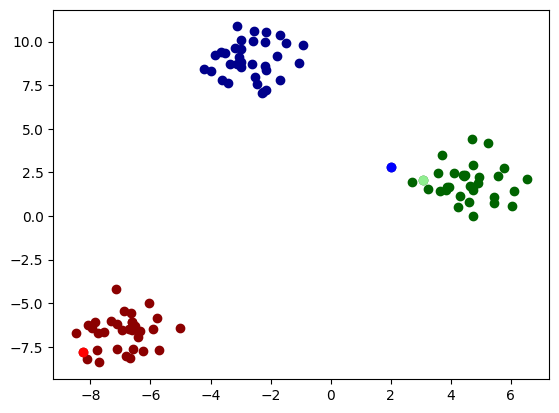

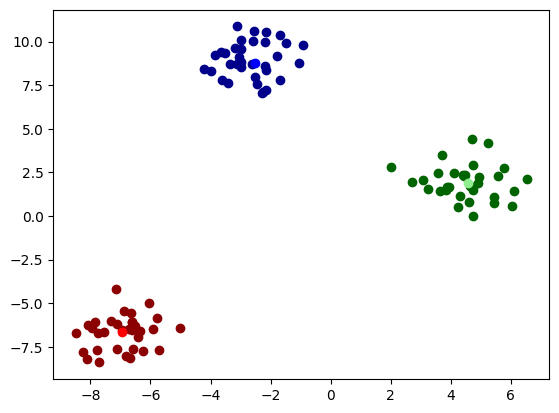

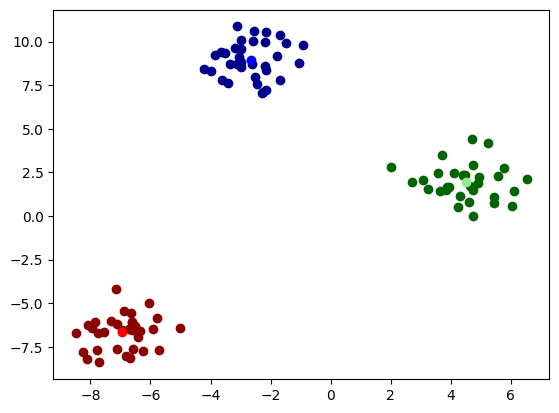

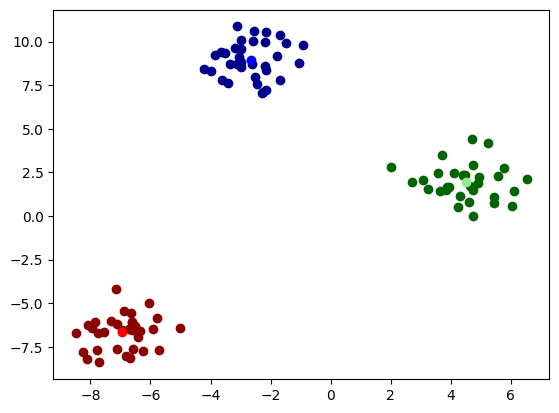

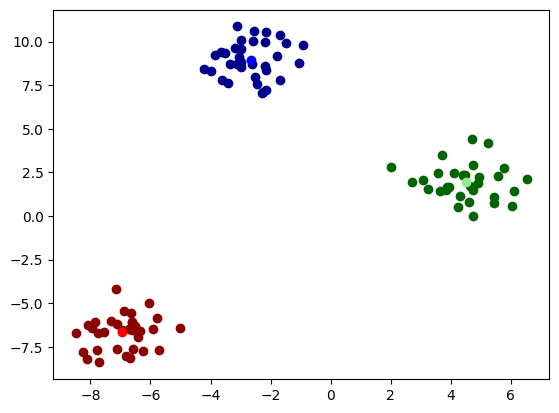

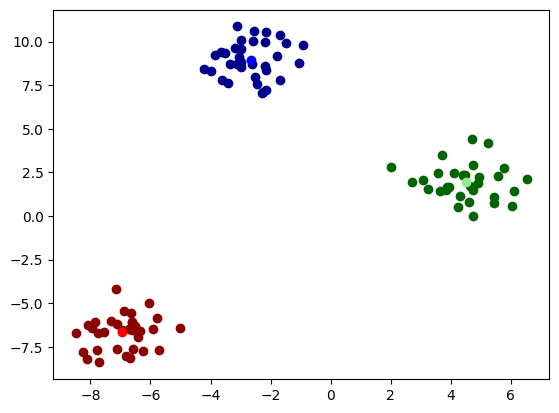

In [ ]:
class KMeans_self_implemented(BaseEstimator, ClassifierMixin):
    def __init__(self, n_clusters=2, init_method='random'):
        self.n_clusters = n_clusters
        self.init_method = init_method

    def fit(self, X):
        def init_clusters(size):
            if self.init_method == 'random':
                return np.random.randint(low=0, high=self.n_clusters, size=size)

        def init_centroids(X):
            init_centroids_vals = X[np.random.choice(X.shape[0], size=self.n_clusters, replace=False)]

            cluster_centroids = {i: init_centroids_vals[i,:] for i in range(init_centroids_vals.shape[0])}
            return cluster_centroids

        def calculate_cluster_centroid(X,y):
            cluster_centroids = {}

            for i in np.unique(y):
                X_gp = X[np.where(y == i)[0]]
                cluster_centroids[i] = (X_gp.mean(axis=0))

            return cluster_centroids

        def d(P, cent):
            return np.sqrt(np.sum((P - cent)**2, axis=1))

        def assign_to_cluster(X, y, cluster_centroids):      
            distances = []
            for cluster_id, cluster_centroid in cluster_centroids.items():
                cent=cluster_centroid
                distances.append(d(X, cent))

            y_new = np.argmin(np.stack(distances), axis=0)
            
            return y_new

        def plot_clusters(X, y, cluster_centroids):
            cent_cols = ["red", "lightgreen", "blue", "black", "mediumslateblue", "firebrick"]
            cols = ["darkred", "darkgreen", "darkblue", "black", "mediumslateblue", "firebrick"]
            for i in np.unique(y):
                X_gp = X[np.where(y == i)[0]]
                
                plt.scatter(X_gp[:,0], X_gp[:,1], c=cols[i])
            
            for i, (cluster_id, cluster_centroid) in enumerate(cluster_centroids.items()):
                plt.scatter(cluster_centroid[0], cluster_centroid[1], c=cent_cols[i])
            plt.show()

    
        y_prev = init_clusters(X.shape[0])
        cluster_centroids = init_centroids(X)
        y_new = assign_to_cluster(X, y_prev, cluster_centroids)
        plot_clusters(X, y_new, cluster_centroids)
        
        for i in range(5):
            cluster_centroids = calculate_cluster_centroid(X, y_new)
            y_new = assign_to_cluster(X, y_new, cluster_centroids)
            plot_clusters(X, y_new, cluster_centroids)


        
        return y

km_SI = KMeans_self_implemented(n_clusters=3)

y = km_SI.fit(X_test)

array([57, 99, 98])

In [ ]:

P = X_test
distances = []
for cluster_id, cluster_centroid in cluster_centroids.items():
    cent=cluster_centroid
    print(cent)
    distances.append(np.sqrt(np.sum((P - cent)**2, axis=1)).reshape(-1,1))









[-1.44226719  2.41694853]
[-1.77691797  0.43855554]
[-1.94306211  1.44990166]


array([[12.50551419, 10.65023594, 11.41790163,  1.        ],
       [ 7.09609761,  7.23669157,  7.43022785,  0.        ],
       [ 7.30333336,  9.19714287,  8.17282308,  0.        ],
       [ 7.70912975,  7.82071808,  8.03392032,  0.        ],
       [10.10566844,  8.25731395,  9.01809788,  1.        ],
       [ 5.19083269,  5.51198145,  5.59257016,  0.        ],
       [ 7.60853197,  9.55969047,  8.5431588 ,  0.        ],
       [ 5.8631147 ,  6.47942801,  6.42388224,  0.        ],
       [ 6.2014747 ,  6.97831394,  6.84459287,  0.        ],
       [ 7.31726811,  9.14739265,  8.12363479,  0.        ],
       [ 6.89906406,  8.77996642,  7.75522979,  0.        ],
       [ 9.53843836,  7.73992615,  8.45555163,  1.        ],
       [10.25488472,  8.38375982,  9.16615606,  1.        ],
       [ 5.82196688,  7.60512181,  6.58413598,  0.        ],
       [ 6.77667085,  8.74710106,  7.73767204,  0.        ],
       [10.95692803,  9.2112371 ,  9.88298601,  1.        ],
       [ 9.91823004,  8.

In [ ]:
distnp.sqrt(np.sum((X_test - value)**2, axis=1))

In [ ]:


def d(P, cent):
    return np.sqrt(np.sum((P - cent)**2, axis=1))
    


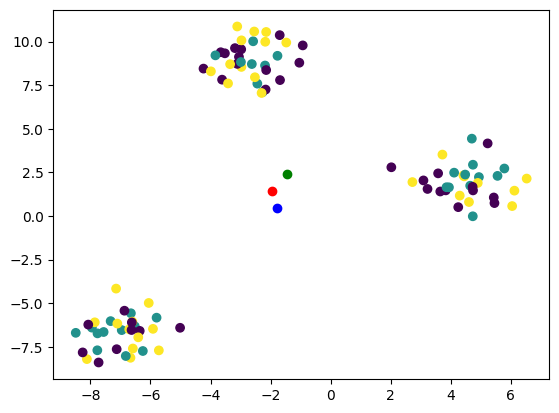

In [110]:
plt.scatter(X_test[:,0], X_test[:,1], c=y)
plt.scatter(cluster_centroids[0][0], cluster_centroids[0][1], c='green')
plt.scatter(cluster_centroids[1][0], cluster_centroids[1][1], c='blue')
plt.scatter(cluster_centroids[2][0], cluster_centroids[2][1], c='red')

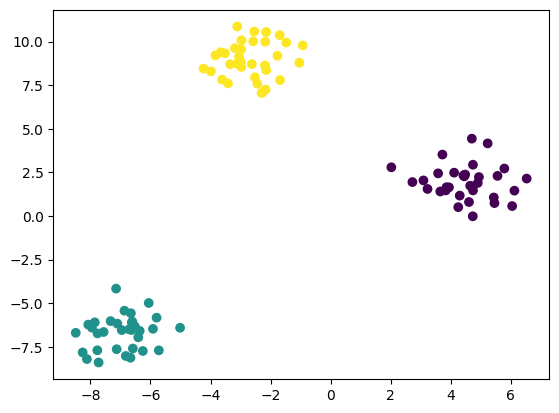

In [339]:
plt.scatter(X[:,0], X[:,1], c=KMeans(n_clusters=3, init='random').fit_predict(X))